# Extracting Attention Weights

In [1]:
import copy
import json
import os
from pathlib import Path
import sys
import warnings

import torch
from anndata import AnnData
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import tqdm

from scipy.sparse import issparse
import scipy as sp
from torch.nn.functional import softmax
from tqdm import tqdm
import pandas as pd

from torchtext.vocab import Vocab
from torchtext.vocab import (
    Vocab as VocabPybind,
)

sys.path.insert(0, "../")

import scgpt as scg
from scgpt.tasks import GeneEmbedding
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.model import TransformerModel
from scgpt.utils import set_seed 
from scgpt.tokenizer import tokenize_and_pad_batch
from scgpt.preprocess import Preprocessor

os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')



/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pip show numpy

Name: numpy
Version: 1.26.4
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2023, NumPy Developers.
        All rights reserved.
        
        Redistribution and use in source and binary forms, with or without
        modification, are permitted provided that the following conditions are
        met:
        
            * Redistributions of source code must retain the above copyright
               notice, this list of conditions and the following disclaimer.
        
            * Redistributions in binary form must reproduce the above
               copyright notice, this list of conditions and the following
               disclaimer in the documentation and/or other materials provided
               with the distribution.
        
            * Neither the name of the NumPy Developers nor the names of any
               contributors may be used to endorse or promo

In [3]:
pip install "numpy<2"


Note: you may need to restart the kernel to use updated packages.


In [4]:
set_seed(42)
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
n_hvg = 1200
n_bins = 51
mask_value = -1
pad_value = -2
n_input_bins = n_bins

## 1. Load Fine-Tuned scGPT model and dataset

### 1.1 Load fine-tuned model

In [5]:
path_model = "../outputs/run-25-07-10-01/"
# Specify model path; here we load the scGPT blood model fine-tuned on adamson
# model_dir = Path("../save/finetuned_scGPT_adamson")
model_config_file = os.path.join(path_model, "args.json")
model_file = os.path.join(path_model, "model_1.pt")
vocab_file = os.path.join(path_model, "vocab.json")

vocab = GeneVocab.from_file(vocab_file)
for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)

# Retrieve model parameters from config files
with open(model_config_file, "r") as f:
    model_configs = json.load(f)
print(
    f"Resume model from {model_file}, the model args will override the "
    f"config {model_config_file}."
)
embsize = model_configs["embsize"]
nhead = model_configs["nheads"]
d_hid = model_configs["d_hid"]
nlayers = model_configs["nlayers"]
# n_layers_cls = model_configs["n_layers_cls"]

gene2idx = vocab.get_stoi()



Resume model from ../outputs/run-25-07-10-01/model_1.pt, the model args will override the config ../outputs/run-25-07-10-01/args.json.


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ntokens = len(vocab)  # size of vocabulary
model = TransformerModel(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    vocab=vocab,
    pad_value=pad_value,
    n_input_bins=n_input_bins,
    use_fast_transformer=True,
    domain_spec_batchnorm = "batchnorm",    #! I added this otherwise self.bn will not initialize
                                            #! https://github.com/bowang-lab/scGPT/issues/134
)

try:
    model = (torch.load(model_file))
    print(f"Loading all model params from {model_file}")
except:
    # only load params that are in the model and match the size
    model_dict = model.state_dict()
    pretrained_dict = torch.load(model_file)
    pretrained_dict = {
        k: v
        for k, v in pretrained_dict.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }
    for k, v in pretrained_dict.items():
        print(f"Loading params {k} with shape {v.shape}")
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict)

model.to(device)



Using simple batchnorm instead of domain specific batchnorm
Loading all model params from ../outputs/run-25-07-10-01/model_1.pt


TransformerModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(60697, 512, padding_idx=60694)
    (enc_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.2, inplace=False)
    (linear1): Linear(in_features=1, out_features=512, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=512, out_features=512, bias=True)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x FlashTransformerEncoderLayer(
        (self_attn): FlashMHA(
          (Wqkv): Linear(in_features=512, out_features=1536, bias=True)
          (inner_attn): FlashAttention()
          (out_proj): Linear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features

### 1.2 Load dataset of interest

In [7]:
adata_file = os.path.join(path_model, "adata_train_1.h5ad")

adata = sc.read(adata_file)

data_is_raw = False

In [8]:
adata.X.shape

(11921, 3497)

In [9]:
# #? What does this do
# filter_gene_by_counts = False 

# preprocessor = Preprocessor(
#     use_key="X",  # the key in adata.layers to use as raw data
#     filter_gene_by_counts=filter_gene_by_counts,  # step 1
#     filter_cell_by_counts=False,  # step 2
#     normalize_total=1e4,  # 3. whether to normalize the raw data and to what sum
#     result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
#     log1p=data_is_raw,  # 4. whether to log1p the normalized data
#     result_log1p_key="X_log1p",
#     subset_hvg=False,  # 5. whether to subset the raw data to highly variable genes
#     hvg_flavor="seurat_v3" if data_is_raw else "cell_ranger",
#     binning=n_bins,  # 6. whether to bin the raw data and to what number of bins
#     result_binned_key="X_binned",  # the key in adata.layers to store the binned data
# )

# preprocessor(adata, batch_key=None)

In [10]:
adata.X.shape

(11921, 3497)

In [11]:
# sc.pp.highly_variable_genes(
#     adata,
#     layer=None,
#     n_top_genes=1200,
#     batch_key="str_batch",
#     flavor="seurat_v3" if data_is_raw else "cell_ranger",
#     subset=False,
# )
# adata.var.loc[adata.var[adata.var.gene_name==TF_name].index, 'highly_variable'] = True
# adata = adata[:, adata.var["highly_variable"]].copy()
# print(adata)



## 2. Retrieve scGPT's attention weights

### 2.1 Prepare model input

In [12]:
#? what is adata layers ? 
input_layer_key = "X_binned"


all_counts = (
    adata.layers[input_layer_key].toarray()
    if issparse(adata.layers[input_layer_key])
    else adata.layers[input_layer_key]
)
genes = adata.var["gene_name"].tolist()
gene_ids = np.array(vocab(genes), dtype=int)



In [13]:
print(type(genes))

<class 'list'>


In [14]:
adata.var

,gene_symbols,gene_name,index,id_in_vocab
10,ABCA1,ABCA1,ABCA1,1
12,ABCA3,ABCA3,ABCA3,1
18,ABL2,ABL2,ABL2,1
20,ABR,ABR,ABR,1
27,ACADSB,ACADSB,ACADSB,1
...,...,...,...,...
18311,NUP43,NUP43,NUP43,1
18432,NDUFS7,NDUFS7,NDUFS7,1
18778,RBM12B,RBM12B,RBM12B,1
19113,SRRD,SRRD,SRRD,1


In [15]:
print(torch.__config__.show())

PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.7
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_37,code=compute_37
  - CuDNN 8.5
  - Magma 2.6.1
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, CUDA_VERSION=11.7, CUDNN_VERSION=8.5.0, CXX_COMPILER=/opt/rh/devtoolset-9/root/usr/bin/c++, CXX_FLAGS= -D_GLIBCXX_USE_CXX11_ABI=0 -fabi-vers

In [16]:
import numpy as np
np.__version__

'1.26.4'

In [17]:
# pip install numpy==1.24.4

In [18]:
batch_size = 4
tokenized_all = tokenize_and_pad_batch(
    all_counts,
    gene_ids,
    max_len=len(genes)+1,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,  # append <cls> token at the beginning
    include_zero_gene=True,
)

In [19]:


all_gene_ids, all_values = tokenized_all["genes"], tokenized_all["values"]
src_key_padding_mask = all_gene_ids.eq(vocab[pad_token])
condition_ids = np.array(adata.obs["disease"].tolist())



In [20]:
all_gene_ids.shape

torch.Size([11921, 3498])

### 2.2 Retrieve scGPT's attention weights

Note that since the flash-attn package does not output attention scores, we manually calculate q @ k.T to extract the attention weights. Users may specify which layer to extract the attention weights from. In the manuscript, we used the attention weights from the last (12th) layer.

In [21]:
torch.cuda.empty_cache()
dict_sum_condition = {}

In [22]:
# Use this argument to specify which layer to extract the attention weights from
# Default to 11, extraction from the last (12th) layer. Note that index starts from 0
num_attn_layers = 11 

In [23]:
from einops import rearrange
model.eval()
dict_attn_by_signature = {}  # key = sample index or unique ID, value = (M x M) matrix
with torch.no_grad(), torch.cuda.amp.autocast(enabled=True):
    M = all_gene_ids.size(1)
    N = all_gene_ids.size(0)
    device = next(model.parameters()).device
    for i in tqdm(range(0, N, batch_size)):
        batch_size = all_gene_ids[i : i + batch_size].size(0)
        outputs = np.zeros((batch_size, M, M), dtype=np.float32)
        # Replicate the operations in model forward pass
        src_embs = model.encoder(torch.tensor(all_gene_ids[i : i + batch_size], dtype=torch.long).to(device))
        val_embs = model.value_encoder(torch.tensor(all_values[i : i + batch_size], dtype=torch.float).to(device))
        total_embs = src_embs + val_embs
        # total_embs = model.bn(total_embs.permute(0, 2, 1)).permute(0, 2, 1)   #! I commented this out because the model wan never trained with
                                                                                #! this attribute - never trained with bn !
        # Send total_embs to attention layers for attention operations
        # Retrieve the output from second to last layer
        for layer in model.transformer_encoder.layers[:num_attn_layers]:
            total_embs = layer(total_embs, src_key_padding_mask=src_key_padding_mask[i : i + batch_size].to(device))
        # Send total_embs to the last layer in flash-attn
        # https://github.com/HazyResearch/flash-attention/blob/1b18f1b7a133c20904c096b8b222a0916e1b3d37/flash_attn/flash_attention.py#L90
        qkv = model.transformer_encoder.layers[num_attn_layers].self_attn.Wqkv(total_embs)
        # Retrieve q, k, and v from flast-attn wrapper
        qkv = rearrange(qkv, 'b s (three h d) -> b s three h d', three=3, h=8)
        q = qkv[:, :, 0, :, :]
        k = qkv[:, :, 1, :, :]
        v = qkv[:, :, 2, :, :]
        # https://towardsdatascience.com/illustrated-self-attention-2d627e33b20a
        # q = [batch, gene, n_heads, n_hid]
        # k = [batch, gene, n_heads, n_hid]
        # attn_scores = [batch, n_heads, gene, gene]
        attn_scores = q.permute(0, 2, 1, 3) @ k.permute(0, 2, 3, 1)
        # Rank normalization by row
        attn_scores = attn_scores.reshape((-1, M))
        order = torch.argsort(attn_scores, dim=1)
        rank = torch.argsort(order, dim=1)
        attn_scores = rank.reshape((-1, 8, M, M))/M
        # Rank normalization by column
        attn_scores = attn_scores.permute(0, 1, 3, 2).reshape((-1, M))
        order = torch.argsort(attn_scores, dim=1)
        rank = torch.argsort(order, dim=1)
        attn_scores = (rank.reshape((-1, 8, M, M))/M).permute(0, 1, 3, 2)
        # Average 8 attention heads
        attn_scores = attn_scores.mean(1)
        
        outputs = attn_scores.detach().cpu().numpy()
        
        for index in range(batch_size):
            dict_attn_by_signature[i + index] = outputs[index, :, :].max(axis=0)
        # for index in range(batch_size):
        #     # Keep track of sum per condition
        #     c = condition_ids[i : i + batch_size][index]
        #     if c not in dict_sum_condition:
        #         dict_sum_condition[c] = np.zeros((M, M), dtype=np.float32)
        #     else:
        #         dict_sum_condition[c] += outputs[index, :, :]


100%|██████████| 2981/2981 [12:02<00:00,  4.13it/s]


In [25]:
dict_attn_by_signature

full_matrix = list()
for i in range(len(dict_attn_by_signature)):
    full_matrix.append(dict_attn_by_signature[i])

full_matrix = np.array(full_matrix)

In [26]:
full_matrix.shape

(11921, 3498)

In [39]:
# save full matrix

output_file = os.path.join(path_model, "attn_matrix.npy")
np.save(output_file, full_matrix)

(array([3.000000e+00, 5.000000e+00, 2.600000e+01, 4.100000e+01,
        1.380000e+02, 3.760000e+02, 8.060000e+02, 1.545000e+03,
        2.728000e+03, 4.302000e+03, 7.139000e+03, 1.087200e+04,
        1.707600e+04, 2.543500e+04, 3.842800e+04, 5.549800e+04,
        7.957700e+04, 1.124860e+05, 1.590210e+05, 2.289350e+05,
        3.247500e+05, 4.483960e+05, 6.024930e+05, 7.817950e+05,
        9.858710e+05, 1.203466e+06, 1.434110e+06, 1.663506e+06,
        1.898063e+06, 2.136534e+06, 2.377639e+06, 2.597969e+06,
        2.782943e+06, 2.916116e+06, 2.991087e+06, 2.994307e+06,
        2.939185e+06, 2.835490e+06, 2.695253e+06, 2.557630e+06,
        2.431394e+06, 2.334618e+06, 2.261345e+06, 2.198543e+06,
        2.144057e+06, 2.069108e+06, 1.962891e+06, 1.822511e+06,
        1.661157e+06, 1.497576e+06, 1.342939e+06, 1.206245e+06,
        1.088710e+06, 9.804900e+05, 8.738140e+05, 7.727730e+05,
        6.749880e+05, 5.842890e+05, 5.008530e+05, 4.252550e+05,
        3.600220e+05, 3.018990e+05, 2.53

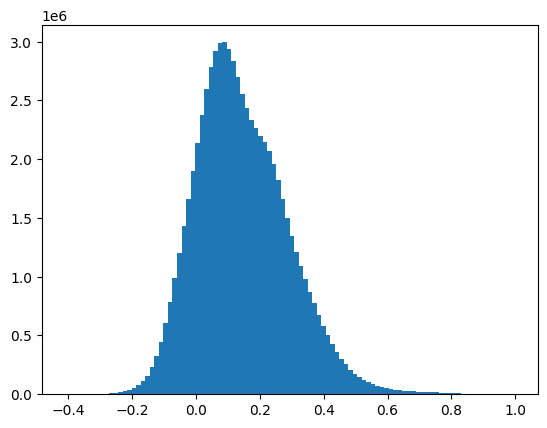

In [40]:
# import pairwise distance
from sklearn.metrics import pairwise_distances

cosine_dist = pairwise_distances(full_matrix, metric='correlation')
cosine_sim = 1 - cosine_dist

# get above upper triangle
all_vals = cosine_sim[np.triu_indices(cosine_sim.shape[0], k=1)]
plt.hist(all_vals, bins=100)

In [43]:
labels = adata.obs["disease"].to_list()

In [52]:
all_pairs_sim = list()
uniq_label = list(set(labels))
for i, label in enumerate(uniq_label):
    _idxs = [j for j, x in enumerate(labels) if x == label]

    if len(_idxs) >= 2:
        # get combination of all pairs
        import itertools
        pairs = list(itertools.combinations(_idxs, 2))
        pairs = np.array(pairs)

        # get similarity for each pair
        pairs_sim = cosine_sim[pairs[:, 0], pairs[:, 1]]
        all_pairs_sim.extend(list(pairs_sim))

In [ ]:
"""1.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports
import pickle
import obonet

# variables
similarity_file = "/aloy/home/ddalton/projects/BQ_diseases/outputs/do_similarity_results.pkl"
similarity_file = "../data/do_similarity_results.pkl"

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata.obs["do_id_study"].unique())

# Define disease embeddings
# d_emb = data_matrix.copy()


# load Disease Ontology Lin Similarity amongst pairs!
results = pickle.load(open(similarity_file, "rb"))


FileNotFoundError: [Errno 2] No such file or directory: '/aloy/home/ddalton/databases/DO_FILES/doid.obo'

In [ ]:

# Load IC based similarity 
do_graph = obonet.read_obo("../data/doid.obo")
dog_graph = nx.DiGraph(do_graph)
dog_graph = dog_graph.reverse()  
leaf_nodes = [n for n, d in dog_graph.out_degree() if d == 0]
print(f"Number of leaf nodes in DO graph: {len(leaf_nodes)}")


do_df_ic = pd.DataFrame(
    results,
    columns=[
        "do1",
        "do2",
        "pair_sorted",
        "resnik",
        "lin",
        "jiang",
        "mica_node",
        "shortest_path_length"
    ]
)

do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print(do_df_ic_query.shape)

# get top 5% of values
ic_thr = np.quantile(do_df_ic_query["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}")

ic_thr_99 = np.quantile(do_df_ic_query["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}")

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")

Number of leaf nodes in DO graph: 9467
(15576, 8)
IC Threshold: 0.418
IC Threshold 99%: 0.605


Processing same disease pairs: 100%|██████████| 177/177 [00:28<00:00,  6.25it/s] 


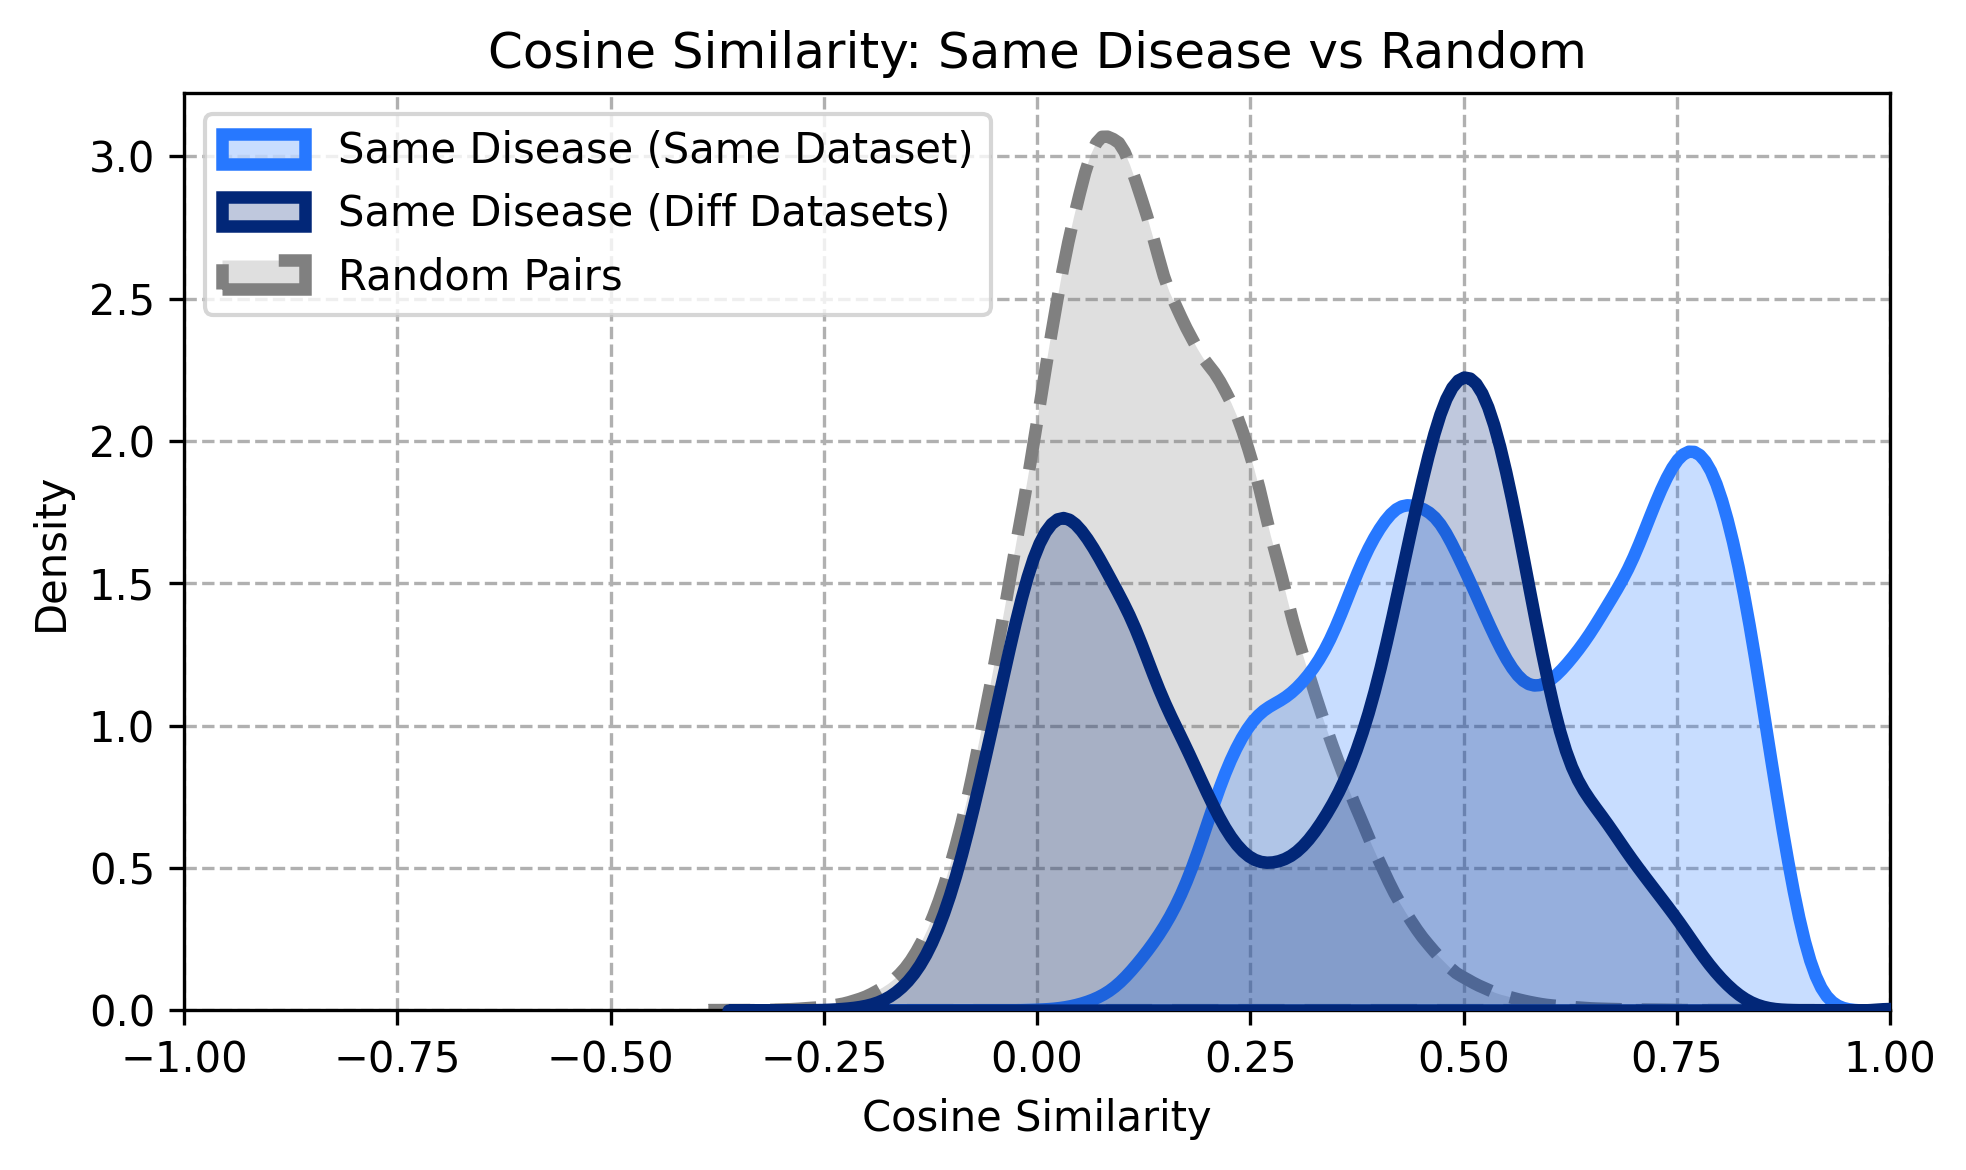

In [81]:

def plot_same_disease_strat_vs_random(
    c_matrix,
    adata_obs,
    df_query,
    color_same="#6baed6",
    color_diff="#08519c",
    color_rand="gray",
    seed=42,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import itertools
    from collections import defaultdict
    from tqdm import tqdm

    np.random.seed(seed)

    flatten = lambda l: [item for sublist in l for item in sublist]

    adata_obs = adata_obs.copy()
    adata_obs.reset_index(drop=True, inplace=True)
    adata_obs["is_control"] = ["C" if i.startswith("Control") else "D" for i in adata_obs["do_id_study"]]

    _c_same_same, _w_same_same = [], []
    _c_same_diff, _w_same_diff = [], []

    # Precompute DOID-to-sample indices
    doid_to_indices = defaultdict(list)
    for idx, doid in adata_obs["do_id_study"].items():
        doid_to_indices[doid].append(idx)

    # Build unrelated pairs
    unrelated_pairs = []
    # pair_key_set = set(tuple(sorted(eval(x))) for x in df_query["pair_sorted"])
    pair_key_set = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    doids = list(doid_to_indices.keys())
    for i in tqdm(range(len(doids)), desc="Building unrelated pairs"):
        for j in range(i + 1, len(doids)):
            d1, d2 = doids[i], doids[j]
            if d1 == d2 or tuple(sorted([d1, d2])) in pair_key_set:
                continue
            unrelated_pairs.extend(itertools.product(doid_to_indices[d1], doid_to_indices[d2]))

    # Process same disease pairs
    for do_id in tqdm(adata_obs["do_id_study"].unique(), desc="Processing same disease pairs"):
        if do_id.startswith("Control"):
            continue
        _df = adata_obs.query("do_id_study == @do_id")
        datasets = _df["dsaid"].unique()

        for dsaid in datasets:
            idxs = _df.query("dsaid == @dsaid").index
            if len(idxs) < 2:
                continue
            idxs_p = np.array(list(itertools.combinations(idxs, 2)))
            _c_same_same.extend(c_matrix[idxs_p[:, 0], idxs_p[:, 1]])
            _w_same_same.extend([len(idxs_p)] * len(idxs_p))

        if len(datasets) > 1:
            for d1, d2 in itertools.combinations(datasets, 2):
                idxs1 = _df.query("dsaid == @d1").index
                idxs2 = _df.query("dsaid == @d2").index
                idxs_p = np.array(list(itertools.product(idxs1, idxs2)))
                _c_same_diff.extend(c_matrix[idxs_p[:, 0], idxs_p[:, 1]])
                _w_same_diff.extend([len(idxs_p)] * len(idxs_p))

    # Normalize weights
    _w_same_same = np.array(_w_same_same) / len(_c_same_same)
    _w_same_diff = np.array(_w_same_diff) / len(_c_same_diff)

    # Sample unrelated pairs
    sample_size = len(_c_same_same) + len(_c_same_diff)
    selected_idxs = np.random.choice(len(unrelated_pairs), size=sample_size, replace=False)
    _rand_sample_pairs = [unrelated_pairs[i] for i in selected_idxs]
    _c_rand = [c_matrix[i, j] for i, j in _rand_sample_pairs]

    # Plot
    plt.figure(figsize=(6.5, 4), dpi=300)

    sns.kdeplot(x=_c_same_same, weights=_w_same_same,linewidth=3,  label="Same Disease (Same Dataset)", fill=True, color=color_same, zorder=3)
    sns.kdeplot(x=_c_same_diff, weights=_w_same_diff,linewidth=3,  label="Same Disease (Diff Datasets)", fill=True, color=color_diff, zorder=3)
    sns.kdeplot(_c_rand, label="Random Pairs", linewidth=3, linestyle="--", fill=True, color=color_rand, zorder=2)

    plt.title("Cosine Similarity: Same Disease vs Random")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.xlim(-1, 1)
    plt.grid(zorder=-3, linestyle="--")
    plt.show()


df_query = do_df_ic_query.copy()
plot_same_disease_strat_vs_random(
    cosine_sim,
    adata.obs,
    df_query,
    color_same="#2778ff",
    color_diff="#022778",
    color_rand="gray",
    seed=42,)

778 unrelated disease pairs
[SP 2] Nº of related disease pairs: 79
[SP 3] Nº of related disease pairs: 126
[SP 5] Nº of related disease pairs: 131
n_needed 157791
len(c_relate) 1577914
157791


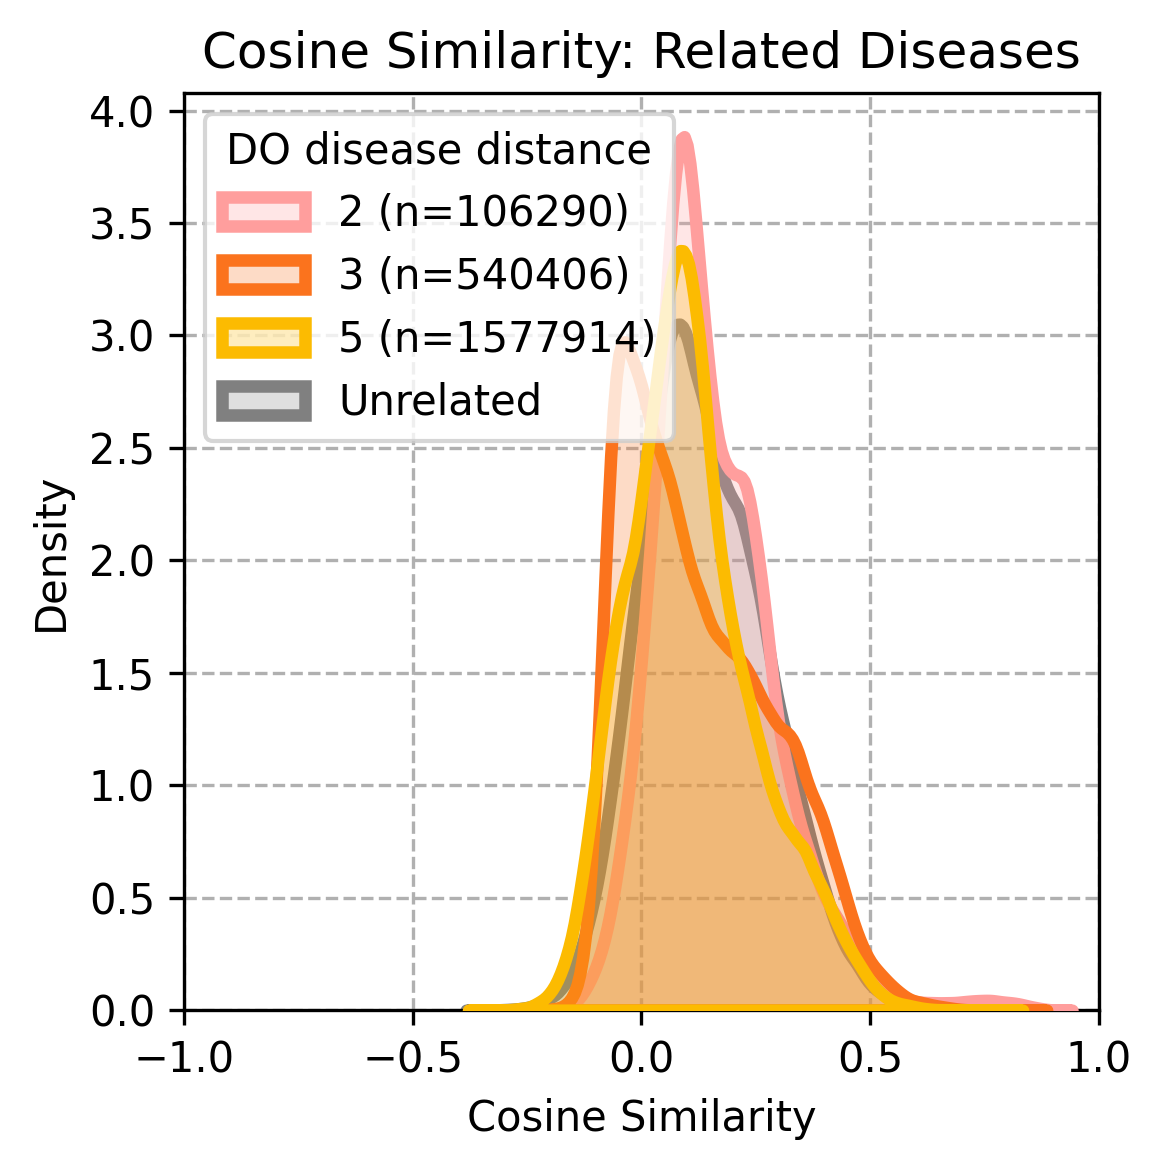

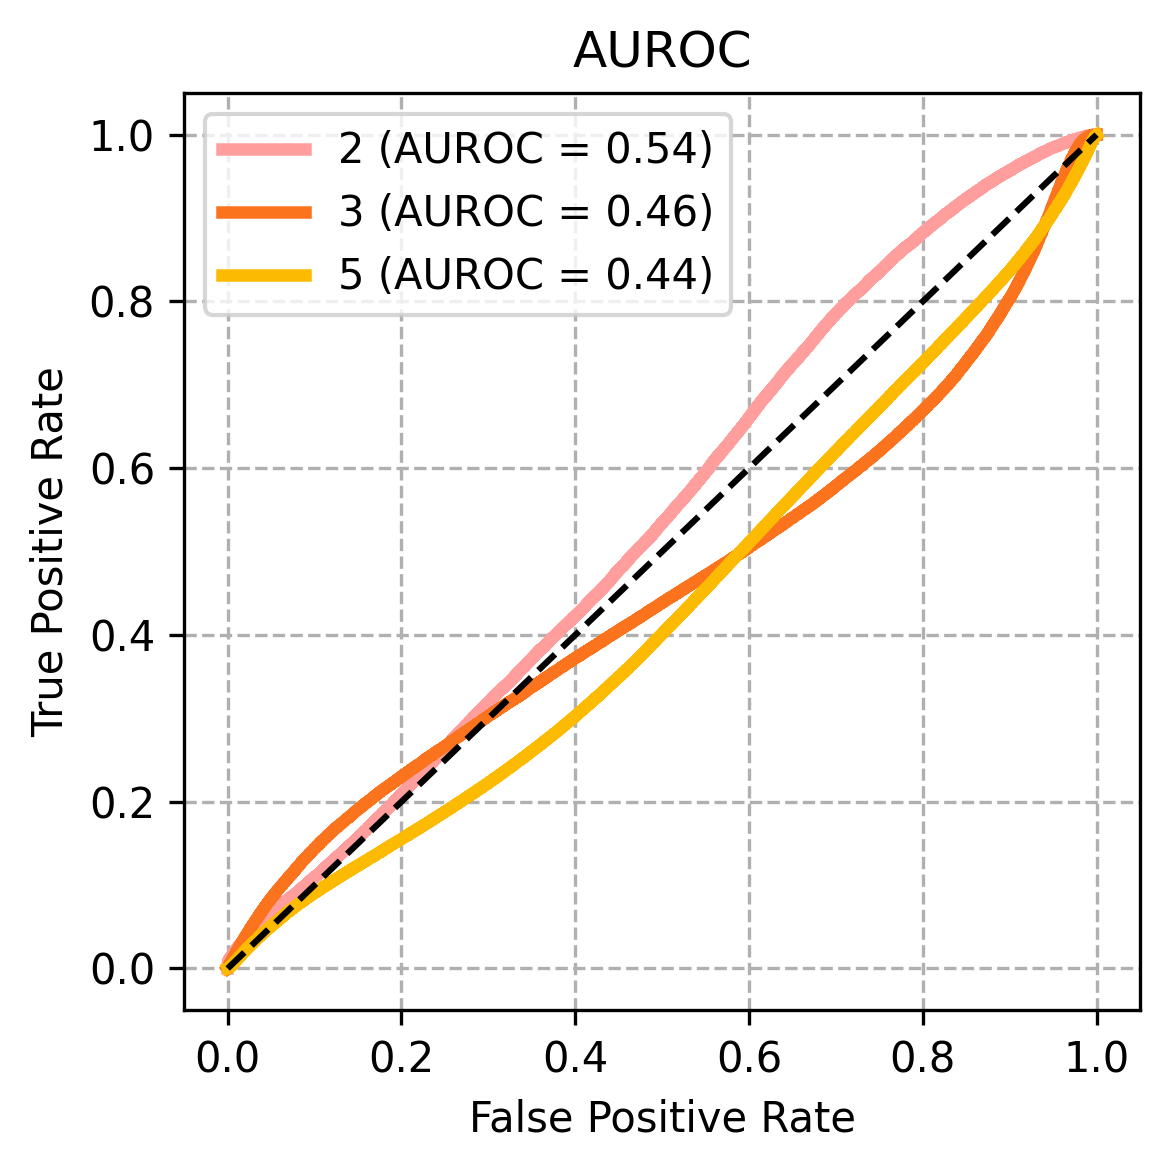

In [80]:
from sklearn.metrics import roc_curve, auc

def plot_kde_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "#2778ff", "#d6f3ff"]  # default palette

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    print(len(unrelated_keys), "unrelated disease pairs")
    do_ids = adata_obs["do_id_study"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        print(f"[SP {sp_val}] Nº of related disease pairs: {len(_df_query)}")

        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related) / len(_c_related)

        sns.kdeplot(
            x=_c_related,
            weights=_w_related,
            label=f"{sp_val} (n={len(_c_related)})",
            fill=True,
            color=colors[i % len(colors)],
            zorder=3,
            linewidth=3,
        )

    # Add shared random baseline
    n_needed = len(_c_related) // 10
    print("n_needed", n_needed)
    print("len(c_relate)", len(_c_related))

    rand_pairs = set()
    while len(rand_pairs) < n_needed:
        a, b = np.random.choice(len(do_ids), 2, replace=False)
        do1, do2 = do_ids[a], do_ids[b]
        if do1 == do2:
            continue
        if tuple(sorted([do1, do2])) in unrelated_keys:
            continue
        rand_pairs.add((a, b))

    rand_pairs = np.array(list(rand_pairs))
    print(len(rand_pairs))
    _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
    sns.kdeplot(_c_rand, label="Unrelated", fill=True, color="gray", linewidth=3,  zorder=2)

    plt.title("Cosine Similarity: Related Diseases")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")

    # plot legend title
    plt.legend(title="DO disease distance")

    plt.tight_layout()
    plt.xlim(-1, 1)
    plt.grid(zorder=-3, linestyle="--")
    plt.show()

def plot_roc_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None, weights_bool=True
):
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "grey","#2778ff", ]

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    do_ids = adata_obs["do_id_study"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related)

        # Negative sampling
        rand_pairs = set()
        while len(rand_pairs) < len(_c_related):
            a, b = np.random.choice(len(do_ids), 2, replace=False)
            do1, do2 = do_ids[a], do_ids[b]
            if do1 == do2:
                continue
            if tuple(sorted([do1, do2])) in unrelated_keys:
                continue
            rand_pairs.add((a, b))
        rand_pairs = np.array(list(rand_pairs))
        _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
        _w_rand = np.ones(len(_c_rand))

        # ROC computation
        y_true = np.concatenate([np.ones(len(_c_related)), np.zeros(len(_c_rand))])
        scores = np.concatenate([_c_related, _c_rand])
        weights = np.concatenate([_w_related, _w_rand])

        if weights_bool:
            fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        else:
            fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{sp_val} (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()



# 2. Plot Similarity
df_query = do_df_ic_query.copy()
# KDE
plot_kde_for_shortest_path_relatedness(
    cosine_sim, adata.obs, df_query, s_p=[2, 3, 5],
)


plot_roc_for_shortest_path_relatedness(
    cosine_sim, adata.obs, df_query, s_p=[2, 3, 5])

<Axes: ylabel='Density'>

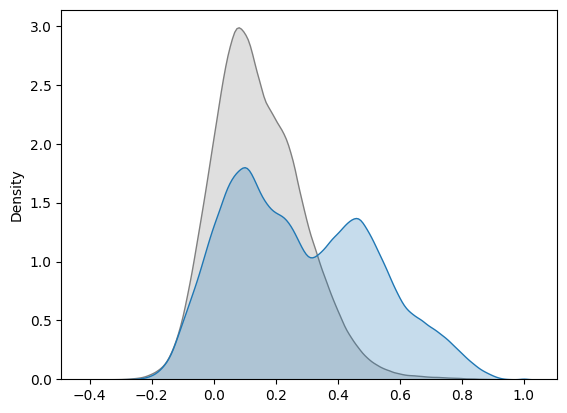

In [59]:
import random
sns.kdeplot(random.choices(all_vals, k=len(all_pairs_sim)), fill=True, color='grey', label='random')
sns.kdeplot(all_pairs_sim,fill=True, label='same disease')

In [50]:
pairs

array([], dtype=float64)

In [48]:
pairs_sim

array([0.39223025, 0.32067554, 0.35234112, ..., 0.56274432, 0.55683825,
       0.74915149])

<Axes: ylabel='Density'>

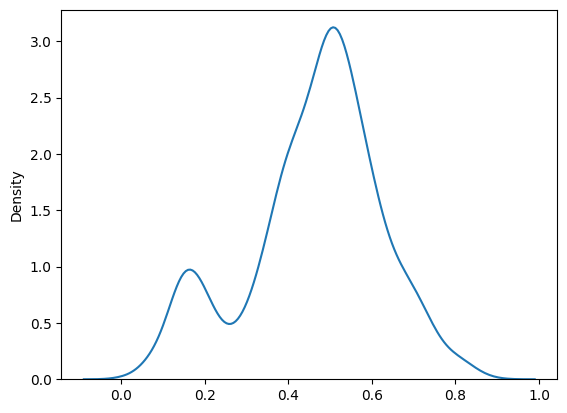

In [47]:
sns.kdeplot(pairs_sim, label=label, color=sns.color_palette()[i])

In [ ]:
dict_sum_condition["Systemic Lupus Erythematosus"]

array([[2656.543 , 2364.7607, 2800.181 , ..., 1394.3608,  888.1521,
        2289.5164],
       [1975.6237, 1835.4897, 1660.955 , ..., 1480.4545, 1875.5251,
        1752.7715],
       [1933.2919, 1681.9335, 2076.8093, ..., 1420.327 , 1612.3995,
        1669.5557],
       ...,
       [2166.4387, 2380.237 , 2054.5127, ..., 2119.0115, 1259.4414,
        2307.4082],
       [1568.2382, 1913.8823, 1804.7013, ..., 2452.968 , 2053.7852,
        1797.7467],
       [2047.2216, 1613.7766, 1741.7886, ..., 1460.2426, 1791.0458,
        1626.0828]], dtype=float32)

### 2.2 Average rank-normed attention weights by condition

In [ ]:
groups = adata.obs.groupby('disease').groups

NameError: name 'adata' is not defined

In [ ]:


dict_sum_condition_mean = dict_sum_condition.copy()
for i in groups.keys():
    dict_sum_condition_mean[i] = dict_sum_condition_mean[i]/len(groups[i])
gene_vocab_idx = all_gene_ids[0].clone().detach().cpu().numpy()



In [ ]:
dict_sum_condition_mean 

{'Myelodysplastic Syndromes': array([[0.7092386 , 0.6538189 , 0.71179336, ..., 0.3624593 , 0.25960413,
         0.62823457],
        [0.5233036 , 0.49049816, 0.44359615, ..., 0.3802084 , 0.47146305,
         0.47588766],
        [0.49477547, 0.45307708, 0.5500393 , ..., 0.3819997 , 0.415729  ,
         0.44644845],
        ...,
        [0.58886707, 0.6584114 , 0.5340308 , ..., 0.56708944, 0.33806795,
         0.64584386],
        [0.4212893 , 0.49071088, 0.5043392 , ..., 0.6804365 , 0.5417939 ,
         0.45955807],
        [0.5529244 , 0.39385685, 0.4390191 , ..., 0.3585763 , 0.5047584 ,
         0.4132912 ]], dtype=float32),
 'Systemic Lupus Erythematosus': array([[0.71823794, 0.63931113, 0.757107  , ..., 0.37697482, 0.24010874,
         0.6190123 ],
        [0.5340864 , 0.49620298, 0.44903222, ..., 0.40020126, 0.50702035,
         0.47386762],
        [0.52265334, 0.45472017, 0.5615007 , ..., 0.38398936, 0.43589953,
         0.451352  ],
        ...,
        [0.5857116 , 0.6435518 ,

In [ ]:
dict_sum_condition_mean["Myelodysplastic Syndromes"][0,]

array([0.7092386 , 0.6538189 , 0.71179336, ..., 0.3624593 , 0.25960413,
       0.62823457], dtype=float32)

In [ ]:
dict_sum_condition_mean["Myelodysplastic Syndromes"]

array([0.7092386 , 0.5233036 , 0.49477547, ..., 0.58886707, 0.4212893 ,
       0.5529244 ], dtype=float32)

## 3. Perform most influenced gene selection


{'whiskers': [<matplotlib.lines.Line2D at 0x7d4b5cf97f40>,
 'caps': [<matplotlib.lines.Line2D at 0x7d4b5cf950c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d4b5cee5cc0>],
 'medians': [<matplotlib.lines.Line2D at 0x7d4b5cf960b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d4b5cf97190>],
 'means': []}

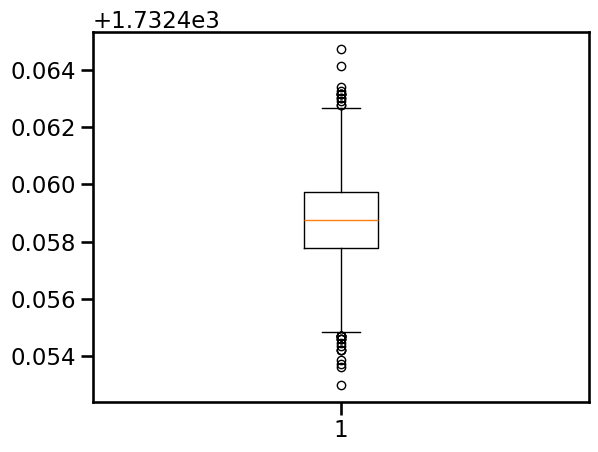

In [ ]:
plt.boxplot(np.sum(dict_sum_condition_mean["Myelodysplastic Syndromes"], axis=0))

In [ ]:
dict_sum_condition_mean["Myelodysplastic Syndromes"]

array([[0.7092386 , 0.6538189 , 0.71179336, ..., 0.3624593 , 0.25960413,
        0.62823457],
       [0.5233036 , 0.49049816, 0.44359615, ..., 0.3802084 , 0.47146305,
        0.47588766],
       [0.49477547, 0.45307708, 0.5500393 , ..., 0.3819997 , 0.415729  ,
        0.44644845],
       ...,
       [0.58886707, 0.6584114 , 0.5340308 , ..., 0.56708944, 0.33806795,
        0.64584386],
       [0.4212893 , 0.49071088, 0.5043392 , ..., 0.6804365 , 0.5417939 ,
        0.45955807],
       [0.5529244 , 0.39385685, 0.4390191 , ..., 0.3585763 , 0.5047584 ,
        0.4132912 ]], dtype=float32)

In [ ]:
    attn_top_gene_dict = {}
    attn_top_scores_dict = {}
    for i in groups.keys():
        if i != 'ctrl':
            knockout_gene = i.split('+')[0]
            knockout_gene_idx = np.where(gene_vocab_idx==vocab([knockout_gene])[0])[0][0]
            control = dict_sum_condition_mean['ctrl'][:, knockout_gene_idx]
            exp = dict_sum_condition_mean[i][:, knockout_gene_idx]
            # Chnage this line to exp, control, exp-control for three different settings
            if setting == 'difference':
                a = exp-control
            elif setting == 'control':
                a = control
            elif setting == 'experiment':
                a = exp
            diff_idx = np.argpartition(a, -topk)[-topk:]
            scores = (a)[diff_idx]
            attn_top_genes = vocab.lookup_tokens(gene_vocab_idx[diff_idx]) + [TF_name]
            attn_top_gene_dict[i] = list(attn_top_genes)
            attn_top_scores_dict[i] = list(scores)

In [ ]:


def get_topk_most_influenced_genes(topk, setting):
    attn_top_gene_dict = {}
    attn_top_scores_dict = {}
    for i in groups.keys():
        if i != 'ctrl':
            knockout_gene = i.split('+')[0]
            knockout_gene_idx = np.where(gene_vocab_idx==vocab([knockout_gene])[0])[0][0]
            control = dict_sum_condition_mean['ctrl'][:, knockout_gene_idx]
            exp = dict_sum_condition_mean[i][:, knockout_gene_idx]
            # Chnage this line to exp, control, exp-control for three different settings
            if setting == 'difference':
                a = exp-control
            elif setting == 'control':
                a = control
            elif setting == 'experiment':
                a = exp
            diff_idx = np.argpartition(a, -topk)[-topk:]
            scores = (a)[diff_idx]
            attn_top_genes = vocab.lookup_tokens(gene_vocab_idx[diff_idx]) + [TF_name]
            attn_top_gene_dict[i] = list(attn_top_genes)
            attn_top_scores_dict[i] = list(scores)
    return attn_top_gene_dict, attn_top_scores_dict






In [ ]:
groups

{'5Q-Syndrome': ['16118', '16115', '16116', '16119', '16120', '16117'], 'Abdominal Aortic Aneurysm': ['9705', '9706', '9702', '9700', '9698', '9704', '9703', '9694', '9693', '9697', '9696'], 'Achalasia': ['28735', '28729', '28726', '28715', '28722', '28725', '28718', '28717', '28721', '28739', '28730', '28727', '28738', '28719', '28732', '28733', '28720', '28714', '28723', '28734', '28716', '28740', '28736', '28724', '28728'], 'Acne': ['38990', '12568', '12569', '38991', '12578', '12571', '12582', '12579', '38989', '38997', '12570', '12566', '38987', '12583', '38993', '12567', '38986', '38995', '38992', '38994'], 'Acute Alcoholic Hepatitis': ['42776', '42781', '42778', '42777', '42780', '42775'], 'Acute Myocardial Infarction': ['2238', '2242', '2235', '2244', '2237', '2232', '2231', '27016', '2247', '2245', '2239', '27017', '2241', '2236', '2240', '2243', '2233'], 'Acute Respiratory Distress Syndrome': ['35435', '35432', '35431', '35433', '35438', '35439', '35430', '35434', '35436', '3

In [ ]:
dict_sum_condition_mean[list(groups.keys())[2]]

array([[0.6854416 , 0.7039437 , 0.76691526, ..., 0.3548042 , 0.24782161,
        0.6325357 ],
       [0.4949828 , 0.4496084 , 0.44585764, ..., 0.35334766, 0.46988133,
        0.44283012],
       [0.47531876, 0.44368783, 0.5250557 , ..., 0.35346335, 0.42392653,
        0.44235855],
       ...,
       [0.5985134 , 0.6561993 , 0.5358977 , ..., 0.54014295, 0.31088334,
        0.6468539 ],
       [0.3781218 , 0.4626258 , 0.45239562, ..., 0.6467539 , 0.51496565,
        0.44599774],
       [0.54006714, 0.3514366 , 0.41046032, ..., 0.31348625, 0.5122241 ,
        0.38059318]], dtype=float32)

In [ ]:

attn_top_gene_dict = {}
attn_top_scores_dict = {}
for i in groups.keys():
    if i != 'ctrl':
        knockout_gene = i.split('+')[0]
        knockout_gene_idx = np.where(gene_vocab_idx==vocab([knockout_gene])[0])[0][0]
        control = dict_sum_condition_mean['ctrl'][:, knockout_gene_idx]
        exp = dict_sum_condition_mean[i][:, knockout_gene_idx]
        # Chnage this line to exp, control, exp-control for three different settings
        if setting == 'difference':
            a = exp-control
        elif setting == 'control':
            a = control
        elif setting == 'experiment':
            a = exp
        diff_idx = np.argpartition(a, -topk)[-topk:]
        scores = (a)[diff_idx]
        attn_top_genes = vocab.lookup_tokens(gene_vocab_idx[diff_idx])
        attn_top_gene_dict[i] = list(attn_top_genes)
        attn_top_scores_dict[i] = list(scores)


In [ ]:
gene_vocab_idx = all_gene_ids[0].clone().detach().cpu().numpy()

In [ ]:
# Specify top k number of genes to be selected, and the selection setting
# Here calculate top 20 most influenced genes for CHIP-Atlas validation
topk = 20
setting = 'difference' # "control", "perturbed"
assert setting in ["difference", "control", "perturbed"]
attn_top_gene_dict_20, attn_top_scores_dict_20 = get_topk_most_influenced_genes(topk, setting)


# Test Area

In [5]:
adata = sc.read("/aloy/home/ddalton/projects/scGPT_playground/outputs/run-25-07-10-01/adata_train_1.h5ad")
# ori_batch_col = "control"
# adata.obs["celltype"] = adata.obs["condition"].astype("category")
# adata.obs["str_batch"] = adata.obs["control"].astype(str)
data_is_raw = True



In [36]:
import logging
from scanpy.pp import combat



def perform_combat_correction(adata) -> AnnData:
    """
    Perform ComBat batch correction on the input AnnData object.

    Parameters:
    - adata: AnnData
        The AnnData object containing the expression data and batch information.

    Returns:
    - AnnData
        The AnnData object with batch-corrected expression data.
    """
    logging.info("Performing batch correction using ComBat.")

    # Impute NaN values with 0 for ComBat compatibility
    imputed_X = adata.X.copy()
    mask_nan = np.isnan(imputed_X)  # Identify original NaN positions
    imputed_X[mask_nan] = 0

    # Temporarily replace `adata.X` with imputed values
    adata.X = imputed_X

    # Apply ComBat for batch correction
    combat(adata, key="batch_id")

    # Restore original NaN values in the batch-corrected matrix
    adata.X[mask_nan] = np.nan

    logging.info("Batch correction completed.")

    return adata


_adata_corr = perform_combat_correction(adata) 

Found 3497 genes with zero variance.


In [ ]:
_adata = sc.read("/aloy/home/ddalton/projects/scGPT_playground/outputs/run-25-07-10-01/adata_orig.h5ad")

print(f"Shape of _adata before preprocessing: {_adata.shape}")

# remove samples from batch_id with only one sample
batch_counts = dict(_adata.obs['batch_id'].value_counts())
_low_count_batches = [k for k, v in batch_counts.items() if v < 2]
mask = _adata.obs['batch_id'].isin(_low_count_batches)
_adata = _adata[~mask].copy()
print(f"Removed {len(_low_count_batches)} batches with less than 2 samples")
print(f"Shape of _adata after removing low count batches: {_adata.shape}")

# Impute NaN values with 0 for ComBat compatibility
imputed_X = _adata.X.copy()
mask_nan = np.isnan(imputed_X)  # Identify original NaN positions
imputed_X[mask_nan] = 0




variances = np.nanvar(_adata.X, axis=0)
zero_var_genes = np.where(variances == 0)[0]
print(f"{len(zero_var_genes)} genes with zero variance")


# print(_adata.obs["batch_id"].isna().sum(), "NaN values in batch_id")
# print("Unique batches:", _adata.obs['batch_id'].unique())
# print("Number of unique batches:", _adata.obs['batch_id'].nunique())
# print(_adata.obs['batch_id'].value_counts())



_adata.X = imputed_X
_adata = combat(_adata, key="batch_id")

_adata.X

Shape of _adata before preprocessing: (20552, 3497)
0 genes with zero variance
Removed 11 batches with less than 2 samples
Shape of _adata after removing low count batches: (20541, 3497)


ValueError: Data matrix has wrong shape (20552, 3497), need to be (20541, 3497).

In [61]:
_adata.X

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [57]:
_adata.obs["batch_id"].value_counts()

batch_id
1177    520
456     334
483     319
742     318
533     299
       ... 
185       1
170       1
181       1
327       1
1127      1
Name: count, Length: 851, dtype: int64

In [52]:
_adata.X

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [47]:
adata

AnnData object with n_obs × n_vars = 11921 × 3497
    obs: 'ids', 'dataset', 'dataset_id', 'batch', 'batch_id', 'dsaid', 'tissue', 'n_genes', 'disease', 'celltype', 'disease_study', 'library', 'do_id_study', 'do_id', 'do_term', 'celltype_id', 'test_split_1', 'test_split_2', 'test_split_3'
    var: 'gene_symbols', 'gene_name', 'index', 'id_in_vocab'
    uns: 'log1p'
    obsm: 'bin_edges'
    layers: 'X_binned', 'X_log1p', 'X_normed'

In [41]:
_adata_corr.X

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [27]:
import pickle

tr_idxs = (pickle.load(open("/aloy/home/ddalton/projects/scGPT_playground/outputs/run-25-07-10-01/train_indices.pkl", "rb")))

In [31]:
_adata_train = _adata[tr_idxs[0]]

In [34]:
adata.obs

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,do_id_study,do_id,do_term,celltype_id,test_split_1,test_split_2,test_split_3
14988,DSA03006;ERR3607138;Case,E-MTAB-8455,E-MTAB-8455,307,206,DSA03006,Skin,19399,Williams Syndrome,chromosomal disease,Williams Syndrome,RNA-Seq,DOID:1928,DOID:0080014,chromosomal disease,4,0,0,1
2882,DSA00666;GSM3021882;Case,GSE111085,GSE111085,759,521,DSA00666,nan,19399,Myelodysplastic Syndrome,hematopoietic system disease,Myelodysplastic Syndrome,RNA-Seq,DOID:0050908,DOID:74,hematopoietic system disease,10,0,1,0
5913,DSA01351;GSM4610643;Case,GSE152287,GSE152287,815,563,DSA01351,nan,17654,Ataxia Telangiectasia,brain disease,Ataxia Telangiectasia,Microarray,DOID:12704,DOID:936,brain disease,1,0,0,1
34395,DSA06325;GSM1875110;Case,GSE72946,GSE72946,436,294,DSA06325,Whole blood,16825,Leptospirosis,disease by infectious agent,Leptospirosis,Microarray,DOID:2297,DOID:0050117,disease by infectious agent,7,0,0,1
34393,DSA06325;GSM1875108;Case,GSE72946,GSE72946,436,294,DSA06325,Whole blood,16825,Leptospirosis,disease by infectious agent,Leptospirosis,Microarray,DOID:2297,DOID:0050117,disease by infectious agent,7,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42657,DSA08323;GSM5714785;Case,GSE190125,GSE190125,636,427,DSA08323,Whole blood,19399,Down Syndrome,chromosomal disease,Down Syndrome,RNA-Seq,DOID:14250,DOID:0080014,chromosomal disease,4,0,0,1
23095,DSA04320;GSM346942;Case,GSE13791,GSE13791,648,439,DSA04320,nan,17043,Chagas Disease,disease by infectious agent,Chagas Disease,Microarray,DOID:12140,DOID:0050117,disease by infectious agent,7,0,1,0
29626,DSA05470;GSM6509772;Case,GSE212126,GSE212126,848,585,DSA05470,Skin,19399,Psoriasis,integumentary system disease,Psoriasis,RNA-Seq,DOID:4398,DOID:16,integumentary system disease,12,0,0,1
30325,DSA05588;GSM6732736;Case,GSE218012,GSE218012,426,288,DSA05588,Skin,19399,Hypermobile Ehlers-Danlos Syndrome,connective tissue disease,Hypermobile Ehlers-Danlos Syndrome,RNA-Seq,DOID:14757,DOID:65,connective tissue disease,6,0,1,0


In [33]:
_adata_train.obs

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,do_id_study,do_id,do_term,celltype_id,test_split_1,test_split_2,test_split_3
9853,DSA02112;GSM1224901;Case,GSE50628,GSE50628,684,684,DSA02112,Blood,17043,Seizure,brain disease,Seizure,Microarray,DOID:11832,DOID:936,brain disease,1,1,0,0
2365,DSA00609;GSM2978782;Case,GSE110147,GSE110147,409,409,DSA00609,Lung,17347,Non-Specific Interstitial Pneumonia,respiratory system disease,Non-Specific Interstitial Pneumonia,Microarray,DOID:2801,DOID:1579,respiratory system disease,16,0,1,0
4650,DSA01092;GSM340362;Case,GSE13501,GSE13501,192,192,DSA01092,nan,17043,Juvenile Idiopathic Arthritis,connective tissue disease,Juvenile Idiopathic Arthritis,Microarray,DOID:676,DOID:65,connective tissue disease,6,0,0,1
22312,DSA04246;GSM336244;Case,GSE13319,GSE13319,576,576,DSA04246,nan,17043,Leiomyoma,connective tissue disease,Leiomyoma,Microarray,DOID:4386,DOID:65,connective tissue disease,6,1,0,0
22310,DSA04246;GSM336242;Case,GSE13319,GSE13319,576,576,DSA04246,nan,17043,Leiomyoma,connective tissue disease,Leiomyoma,Microarray,DOID:4386,DOID:65,connective tissue disease,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29912,DSA05572;GSM6711468;Case,GSE217320,GSE217320,1074,1074,DSA05572,Blood,19399,Post-Traumatic Stress Disorder,cognitive disorder,Post-Traumatic Stress Disorder,RNA-Seq,DOID:2055,DOID:1561,cognitive disorder,5,1,0,0
12877,DSA02491;GSM1060178;Case,GSE43292,GSE43292,874,874,DSA02491,Heart,17347,Atherosclerosis,cardiovascular system disease,Atherosclerosis,Microarray,DOID:5162,DOID:1287,cardiovascular system disease,2,1,0,0
17218,DSA03409;GSM830058;Case,GSE33566,GSE33566,717,717,DSA03409,Peripheral blood,11439,Idiopathic Pulmonary Fibrosis,connective tissue disease,Idiopathic Pulmonary Fibrosis,Microarray,DOID:0050156,DOID:65,connective tissue disease,6,1,0,0
17984,DSA03473;GSM863062;Case,GSE35179,GSE35179,634,634,DSA03473,Peripheral blood,17600,Chronic Lymphocytic Leukemia,immune system cancer,Chronic Lymphocytic Leukemia,Microarray,DOID:1703,DOID:0060083,immune system cancer,11,0,1,0


In [24]:
_adata.X

array([[ 916.        ,  208.        ,  336.        , ...,  278.        ,
         243.        ,  549.        ],
       [ 613.        ,  163.        ,  294.        , ...,  320.        ,
         209.        ,  314.        ],
       [ 993.        ,  261.        ,  757.        , ...,  759.        ,
         333.        , 1110.        ],
       ...,
       [   7.26445157,    6.49851683,    6.99124428, ...,    4.46375329,
           7.30321932,   10.71790239],
       [   6.96726155,    6.60074652,    6.89104877, ...,    4.60019339,
           7.69202041,    9.30862627],
       [   8.73293792,    5.95955364,    6.27288701, ...,    4.34785428,
           7.28909049,   11.69414055]])

In [26]:
adata.X

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [19]:
preprocessor = Preprocessor(
    use_key="X",  # the key in adata.layers to use as raw data
    filter_gene_by_counts=3,  # step 1
    filter_cell_by_counts=False,  # step 2
    normalize_total=1e4,  # 3. whether to normalize the raw data and to what sum
    result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=data_is_raw,  # 4. whether to log1p the normalized data
    result_log1p_key="X_log1p",
    subset_hvg= False,  # 5. whether to subset the raw data to highly variable genes
    hvg_flavor="seurat_v3" if data_is_raw else "cell_ranger",
    binning=n_bins,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data
)
preprocessor(adata, batch_key="str_batch")

ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
adata

14988             chromosomal disease
2882     hematopoietic system disease
5913                    brain disease
34395     disease by infectious agent
34393     disease by infectious agent
                     ...             
42657             chromosomal disease
23095     disease by infectious agent
29626    integumentary system disease
30325       connective tissue disease
28438     reproductive system disease
Name: celltype, Length: 11921, dtype: category
Categories (19, object): ['X-linked monogenic disease', 'brain disease', 'cardiovascular system disease', 'cell type cancer', ..., 'reproductive system disease', 'respiratory system disease', 'sensory system disease', 'urinary system disease']